In [65]:
import pickle

def load_pickle(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data    

In [66]:
import os 
import pickle
from pprint import pprint

relative_dir = r"data\2019"
ids = os.listdir(relative_dir)
ids.sort(reverse=True)

raw_data = {}
for id in ids:
    with open(os.path.join(relative_dir, id), "rb") as f:
        data = pickle.load(f)[0]
        raw_data[id] = data
print(raw_data)

{'934.pkl': ['Activities at 2019-01-04: Fast Food Restaurant#2441 at 09:20:00, Gourmet Shop#120 at 10:30:00, Korean Restaurant#257 at 13:30:00, Cafe#838 at 14:20:00, Multiplex#283 at 15:10:00, Soba Restaurant#48 at 18:50:00.', 'Activities at 2019-01-05: Betting Shop#44 at 09:30:00, Plaza#960 at 10:50:00, Fast Food Restaurant#2088 at 11:20:00, Movie Theater#130 at 12:10:00, Coffee Shop#2108 at 15:10:00, Drugstore#67 at 16:30:00, Japanese Family Restaurant#1248 at 17:50:00.', 'Activities at 2019-01-13: Japanese Family Restaurant#1248 at 09:00:00, Multiplex#283 at 10:50:00, Fast Food Restaurant#1719 at 13:50:00, Bookstore#1026 at 15:30:00, Convenience Store#8973 at 18:30:00, Donburi Restaurant#31 at 18:50:00.', 'Activities at 2019-02-03: Sushi Restaurant#2194 at 11:30:00, Supermarket#294 at 12:30:00, Drugstore#67 at 13:20:00, Coffee Shop#2108 at 13:30:00, Betting Shop#44 at 15:40:00, Electronics Store#1064 at 18:00:00, Donburi Restaurant#31 at 18:20:00.', 'Activities at 2019-02-09: Fast F

In [67]:
location_category_map = load_pickle(r"data\location_activity_map.pkl")

In [75]:
vset= set()
for k, v in location_category_map.items():
    vset.add(v)
print(len(vset))
print(vset)

10
{'College & University', 'Outdoors & Recreation', 'Residence', 'Event', 'Nightlife Spot', 'Arts & Entertainment', 'Shop & Service', 'Travel & Transport', 'Professional & Other Places', 'Food'}


In [69]:
import re
import random
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from collections import defaultdict

In [70]:
# ==========================================
# 2. 数据预处理与特征提取
# ==========================================

def parse_trajectory(trajectory_list, mapping_dict):
    """
    解析一个人的所有轨迹，将其转化为 broad category 的序列字符串。
    例如: "Leisure Entertainment Food Food Food"
    """
    person_categories = []
    
    # 正则表达式：匹配 "LocationName#ID" 格式中的 LocationName
    # 假设格式总是 "Name#ID at Time"
    pattern = re.compile(r"([a-zA-Z ]+)#\d+")
    
    for day_record in trajectory_list:
        # 提取这一天所有的地点名称
        matches = pattern.findall(day_record)
        for loc_name in matches:
            loc_name = loc_name.strip()
            # 查找映射字典，如果找不到则标记为 Unknown
            category = mapping_dict.get(loc_name, "Unknown")
            category = category.replace(" ", "_")  # 用下划线替换空格
            person_categories.append(category)
            
    return " ".join(person_categories)

# 构建语料库：每个人对应一个由类别组成的字符串
corpus = []
person_ids = []

for pid, trajectories in raw_data.items():
    category_sequence = parse_trajectory(trajectories, location_category_map)
    corpus.append(category_sequence)
    person_ids.append(pid)

print("--- 解析后的类别序列 ---")
for pid, seq in zip(person_ids, corpus):
    print(f"{pid}: {seq}")
    break

--- 解析后的类别序列 ---
934.pkl: Food Shop_&_Service Food Food Arts_&_Entertainment Food Shop_&_Service Outdoors_&_Recreation Food Arts_&_Entertainment Food Shop_&_Service Food Food Arts_&_Entertainment Food Shop_&_Service Shop_&_Service Food Food Shop_&_Service Shop_&_Service Food Shop_&_Service Shop_&_Service Food Food Shop_&_Service Arts_&_Entertainment Food Food Travel_&_Transport Food Shop_&_Service Food Professional_&_Other_Places Food Shop_&_Service Arts_&_Entertainment Shop_&_Service Shop_&_Service Food Arts_&_Entertainment Food Shop_&_Service Shop_&_Service Shop_&_Service Professional_&_Other_Places Shop_&_Service Food Arts_&_Entertainment Professional_&_Other_Places Shop_&_Service Food Travel_&_Transport Food Food Food Outdoors_&_Recreation Food Nightlife_Spot Food Professional_&_Other_Places Shop_&_Service Food Arts_&_Entertainment Shop_&_Service Food Professional_&_Other_Places Food Food Shop_&_Service Professional_&_Other_Places Food Food Shop_&_Service Food Arts_&_Entertainment 

In [71]:
# ==========================================
# 3. 向量化 (TF-IDF)
# ==========================================
# 我们使用 TF-IDF 将文本序列转换为数值向量。
# 这意味着如果某个人经常去别人不常去的地方，那个特征权重会高；
# 同时也统计了频率。
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(X.shape)

# 转换为数组以便查看
dense_X = X.toarray()
features = vectorizer.get_feature_names_out()


(93, 16)


K值    | Inertia (SSE)   | 轮廓系数 (Silhouette)   
---------------------------------------------
3     | 12.1292         | 0.2333              
4     | 9.9195          | 0.2669              
5     | 8.9473          | 0.2421              
6     | 7.8970          | 0.2444              
7     | 7.0869          | 0.2561              
8     | 6.3806          | 0.2037              
9     | 5.6781          | 0.2189              
10    | 5.2389          | 0.2313              


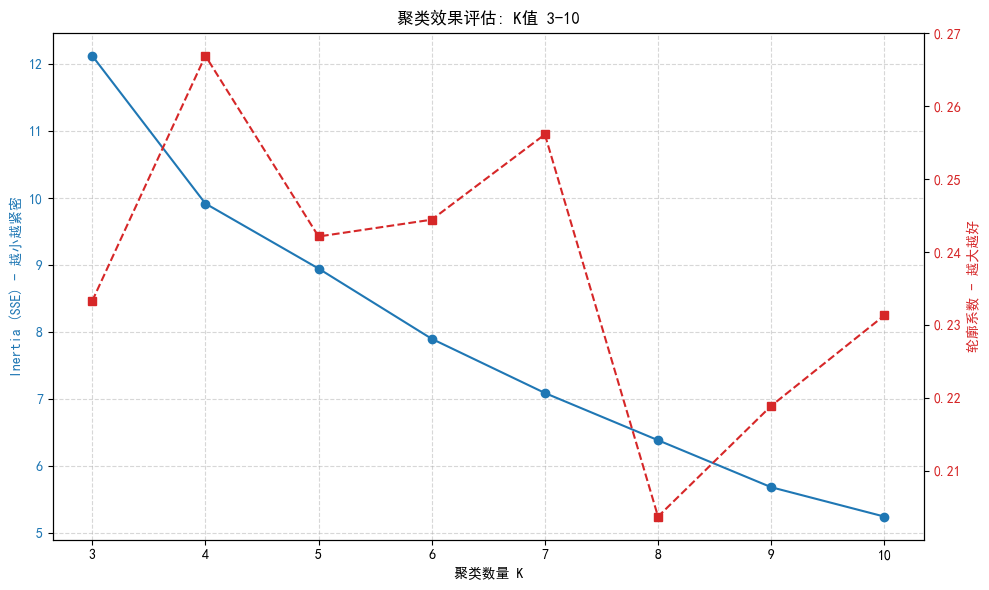

In [72]:
# %%
# ==========================================
# 4. 聚类效果评估 (寻找最佳 K 值)
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 设置字体以支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows自带字体，Mac可能需要改为 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

inertia_scores = []    # 存储 SSE (肘部法则)
silhouette_scores = [] # 存储 轮廓系数
k_range = range(3, 11) # 聚类范围 3 到 10

print(f"{'K值':<5} | {'Inertia (SSE)':<15} | {'轮廓系数 (Silhouette)':<20}")
print("-" * 45)

# 循环计算不同 K 值的效果
for k in k_range:
    # 注意：如果样本量少于 K 值，KMeans 会报错或警告，这里假设样本量足够
    temp_kmeans = KMeans(n_clusters=k, random_state=13, n_init=10)
    temp_kmeans.fit(X)
    
    # 记录 SSE
    inertia_scores.append(temp_kmeans.inertia_)
    
    # 记录 轮廓系数
    s_score = silhouette_score(X, temp_kmeans.labels_)
    silhouette_scores.append(s_score)
    
    print(f"{k:<5} | {temp_kmeans.inertia_:<15.4f} | {s_score:<20.4f}")

# --- 绘制评估图表 ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制 SSE (左轴)
color = 'tab:blue'
ax1.set_xlabel('聚类数量 K')
ax1.set_ylabel('Inertia (SSE) - 越小越紧密', color=color)
ax1.plot(k_range, inertia_scores, marker='o', color=color, label='Inertia (SSE)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# 绘制 轮廓系数 (右轴)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('轮廓系数 - 越大越好', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('聚类效果评估: K值 3-10')
plt.tight_layout()
plt.show()


In [73]:
# %%
# ==========================================
# 5. 使用最佳 K 值进行最终聚类
# ==========================================

# 策略：自动选择轮廓系数最高的 K 值
best_k_index = np.argmax(silhouette_scores)
best_k = k_range[best_k_index]
best_score = silhouette_scores[best_k_index]

print(f"\n>>> 自动选择的最佳聚类数量为: K={best_k} (轮廓系数: {best_score:.4f})")

# 使用最佳 K 重新训练模型
final_kmeans = KMeans(n_clusters=best_k, random_state=13, n_init=10)
final_kmeans.fit(X)
labels = final_kmeans.labels_

# 打印聚类结果摘要
clusters = defaultdict(list)
for pid, label in zip(person_ids, labels):
    clusters[int(label)].append(pid)

print("\n--- 最终聚类结果详情 ---")
for label, pids in clusters.items():
    print(f"Cluster {label} (共{len(pids)}人): {', '.join(pids[:5])}..." if len(pids)>5 else f"Cluster {label}: {', '.join(pids)}")



>>> 自动选择的最佳聚类数量为: K=4 (轮廓系数: 0.2669)

--- 最终聚类结果详情 ---
Cluster 2 (共17人): 934.pkl, 930.pkl, 6463.pkl, 6249.pkl, 6144.pkl...
Cluster 0 (共45人): 914.pkl, 884.pkl, 835.pkl, 7626.pkl, 7266.pkl...
Cluster 1 (共25人): 7259.pkl, 6973.pkl, 6863.pkl, 6693.pkl, 6171.pkl...
Cluster 3 (共6人): 6156.pkl, 606.pkl, 540.pkl, 2390.pkl, 225.pkl...


In [74]:
# %%
# ==========================================
# 6. 为可视化准备数据 (PCA 降维) 并输出 HTML
# ==========================================
import json

# 将高维 TF-IDF 向量降维到 2D 以便绘图
pca = PCA(n_components=2)
coords = pca.fit_transform(dense_X)

# 生成用于 HTML 可视化的 JSON 数据
visualization_data = []
for i, pid in enumerate(person_ids):
    visualization_data.append({
        "id": pid,
        "x": float(coords[i, 0]),
        "y": float(coords[i, 1]),
        "cluster": int(labels[i]),
        "details": corpus[i] # 显示这个人的行为特征
    })

json_output = json.dumps(visualization_data)
print("\n--- JSON Data Generated ---")
# print(json_output) # 数据量大时建议注释掉

# 读取模板并写入结果
try:
    with open('cluster_template.html', 'r', encoding='utf-8') as f: # 建议加上 encoding='utf-8'
        s = f.read()
    
    # 替换占位符
    s = s.replace("<marker></marker>", str(json_output))
    
    # 写入新文件
    output_filename = f'cluster_output.html'
    with open(output_filename, 'w', encoding='utf-8') as f:
        f.write(s)
        
    print(f"\n成功生成可视化文件: {output_filename}")
    
except FileNotFoundError:
    print("\n错误: 未找到 'cluster_template.html' 模板文件，无法生成 HTML。")


--- JSON Data Generated ---

成功生成可视化文件: cluster_output.html
